# Data Visualization: Monetary & Fiscal Agreement and Stance

This notebook produces publication charts for the Article IV traction analysis.

**Data source:** `df_fin.csv` — the pre-merged final dataset from `results_data_transformation.ipynb`.  
**Period:** 2015–2023 | **Sectors:** Monetary & Fiscal

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import data_vis_utils as dv

#### Define some params for charting 

In [6]:

# ── Income group ──────────────────────────────────────────────────────────────
INCOME_GROUP_ORDER = ["AE", "EM", "LIC"]
INCOME_COLORS = {"AE": "#2E5C8A", "EM": "#8EBDD6", "LIC": "#2C9D5F"}

# ── Line plots by group ──────────────────────────────────────────────────────
LINE_GROUPS = ["ALL", "AE", "EM", "LIC"]
LINE_COLORS = {"ALL": "#E74C3C", "AE": "#1F4788", "EM": "#7DC8E8", "LIC": "#27AE60"}

# ── Agreement stacked bars ────────────────────────────────────────────────────
AGREEMENT_ORDER = ["mostly agree", "disagreement exists", "irrelevant"]
AGREEMENT_COLORS = {
    "mostly agree":        "#1F4788",
    "disagreement exists": "#E74C3C",
    "irrelevant":          "#95A5A6",
}

# ── Stance distribution stacked bars (5 consolidated categories) ──────────────
STANCE_ORDER = [
    "tightening", "tightening bias", "no change / unclear",
    "loosening bias", "loosening",
]
STANCE_COLORS = {
    "tightening":          "#1F77B4",
    "tightening bias":     "#8ECAE6",
    "no change / unclear": "#DCEEF8",
    "loosening bias":      "#F4A582",
    "loosening":           "#B2182B",
}

# ── Current stance (for confusion matrices) ──────────────────────────────────
STANCE_CURRENT_ORDER = ["accommodative", "neutral", "restrictive"]

# ── IMF vs Authority comparison ──────────────────────────────────────────────
IMF_VS_AUTH_ORDER = list(dv.DEFAULT_IMF_VS_AUTH_ORDER)
IMF_VS_AUTH_COLORS = {
    "significantly tighter": "#1f77b4",
    "tighter":               "#4aa3df",
    "moderately tighter":    "#bcdff5",
    "same":                  "#f2f2f2",
    "moderately looser":     "#f7c6ae",
    "looser":                "#e76f51",
}

# ── Policy mix ───────────────────────────────────────────────────────────────
POLICY_MIX_ORDER = [
    "MtFt", "MtFn", "MtFl",
    "MnFt", "MnFn", "MnFl",
    "MlFt", "MlFn", "MlFl",
]
POLICY_MIX_CMAP = plt.cm.get_cmap("tab10", len(POLICY_MIX_ORDER))

# ── Monetary disagreement area categories & colors ────────────────────────────
MONETARY_DISAGREE_CATEGORIES = {
    "future policy direction":    ["future policy direction", "forward guidance", "policy path"],
    "monetary policy operations": ["monetary policy operations", "policy operations"],
    "monetary policy framework":  ["monetary policy framework", "policy framework"],
    "current policy stance":      ["current policy stance", "policy stance"],
    "central bank communication": ["monetary policy communication",
                                   "central bank communication", "communication"],
    "institutions":               ["institutions", "independence", "governance"],
    "economic assessment":        ["economic assessment"],
    "exchange rate policy":       ["exchange rate policy", "exchange rate regime",
                                   "exchange rate flexibility"],
    "reserve requirements":       ["reserve requirements"],
    "inflation target":           ["inflation target"],
}
MONETARY_AREA_COLORS = {
    "future policy direction":    "#2E5C8A",
    "monetary policy operations": "#A8CAE1",
    "monetary policy framework":  "#4CAF50",
    "current policy stance":      "#C8E6C9",
    "central bank communication": "#E74C3C",
    "institutions":               "#FCE4EC",
    "economic assessment":        "#FF9800",
    "exchange rate policy":       "#FFD54F",
    "reserve requirements":       "#9C27B0",
    "inflation target":           "#E1BEE7",
}

# ── Fiscal disagreement area categories & colors ──────────────────────────────
FISCAL_DISAGREE_CATEGORIES = {
    "near-term policy direction": ["near-term", "short term", "frontload",
        "front-loaded", "immediate", "next year", "this year",
        "fiscal tightening", "fiscal easing", "pace of"],
    "medium-term fiscal stance":  ["medium-term", "medium term",
        "over the medium term", "fiscal stance", "fiscal adjustment path",
        "gradual", "consolidation path", "trajectory"],
    "fiscal revenue":             ["revenue", "tax", "vat", "gst", "income tax",
        "corporate tax", "tax base", "tax administration", "collection", "customs"],
    "fiscal expenditure":         ["expenditure", "spending", "current spending",
        "wage bill", "public wage", "subsid", "transfer", "social spending",
        "pension", "capital spending", "public investment", "infrastructure"],
    "government debt & financing":["debt", "borrowing", "financing", "rollover",
        "refinancing", "debt sustainability", "debt dynamics",
        "gross financing needs", "bond", "issuance"],
    "economic assessment":        ["economic outlook", "growth", "inflation",
        "output gap", "macroeconomic", "baseline", "downside risk", "risk",
        "shock", "forecast"],
    "fiscal framework":           ["fiscal rule", "framework", "mtbf",
        "medium-term budget framework", "fiscal responsibility",
        "escape clause", "budget process", "transparency"],
    "political commitment":       ["political", "commitment", "ownership",
        "parliament", "election", "public support", "social consensus",
        "implementation"],
}
FISCAL_AREA_COLORS = {
    "near-term policy direction":  "#2E5C8A",
    "fiscal revenue":              "#A8CAE1",
    "government debt & financing": "#2C9D5F",
    "fiscal expenditure":          "#C8E6C9",
    "economic assessment":         "#E74C3C",
    "medium-term fiscal stance":   "#F7A1A8",
    "fiscal framework":            "#FF9800",
    "political commitment":        "#FFD54F",
}


# ── Helper: compute stance share by year ─────────────────────────────────────
def _stance_share_by_year(data, col, order):
    """Group *col* by year, fill missing categories, return proportions."""
    tmp = data.dropna(subset=[col]).copy()
    tmp = tmp[~tmp[col].isin(["irrelevant"])]
    ct = tmp.groupby(["year", col]).size().unstack(fill_value=0)
    for s in order:
        if s not in ct.columns:
            ct[s] = 0
    ct = ct[order]
    return ct.div(ct.sum(axis=1), axis=0)

/tmp/ipykernel_1587849/3033081847.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  POLICY_MIX_CMAP = plt.cm.get_cmap("tab10", len(POLICY_MIX_ORDER))


In [7]:
# ── Data ──────────────────────────────────────────────────────────────────────
DATA_PATH = Path("/data/home/xiong/data/Fund/CSR/Tractions/output/df_fin.csv")
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns from {DATA_PATH.name}")

Loaded 981 rows, 43 columns from df_fin.csv


## Part 1: Overview

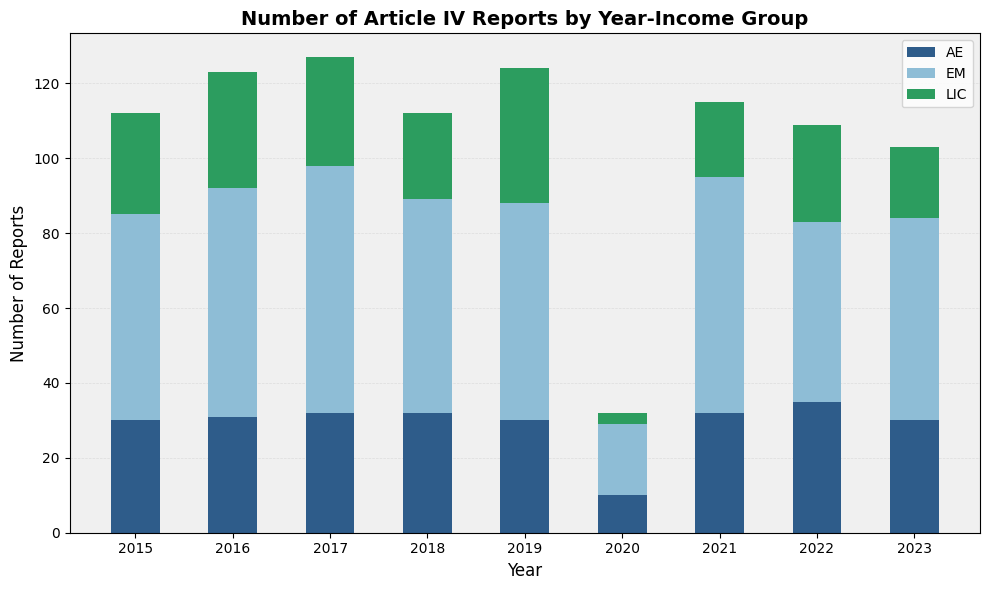

In [8]:
# Chart 1: Stacked bar — Number of Article IV Reports by Year-Income Group
counts = dv.compute_year_group_counts(
    df, year_col="year", group_col="income_group", group_order=INCOME_GROUP_ORDER,
)
dv.plot_stacked_counts_by_year(
    counts, group_order=INCOME_GROUP_ORDER, colors=INCOME_COLORS,
    title="Number of Article IV Reports by Year-Income Group",
)
plt.show()

In [9]:
# Summary table
print("Reports per year:")
print(counts)
print(f"\nTotal reports: {len(df)}")

Reports per year:
income_group  AE  EM  LIC
year                     
2015          30  55   27
2016          31  61   31
2017          32  66   29
2018          32  57   23
2019          30  58   36
2020          10  19    3
2021          32  63   20
2022          35  48   26
2023          30  54   19

Total reports: 981


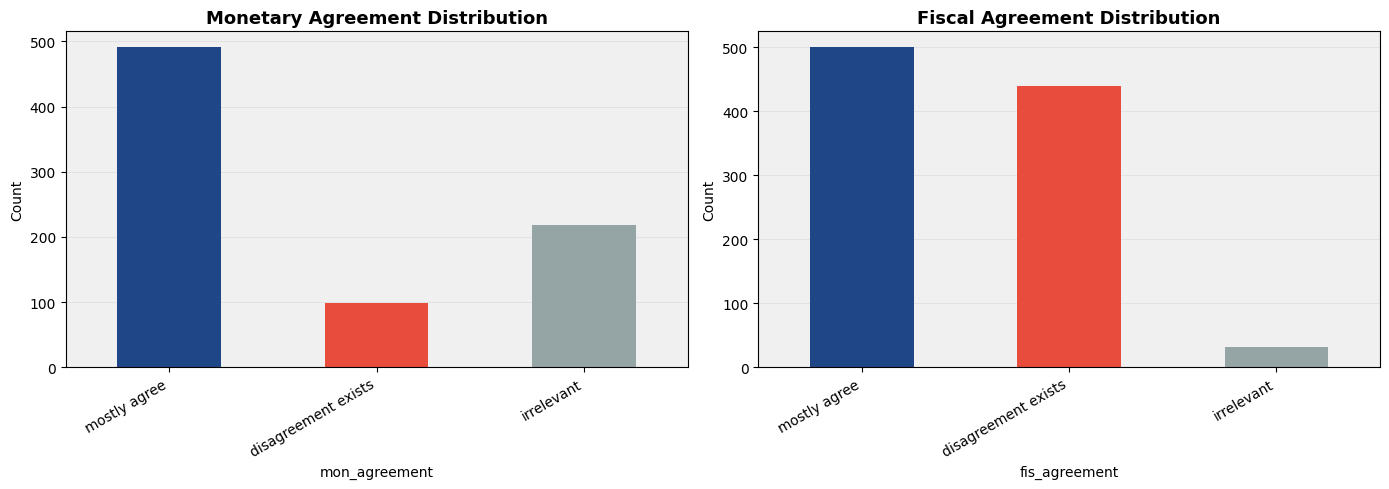

In [10]:
# Agreement distribution bar charts (monetary & fiscal side-by-side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
    ["mon_agreement", "fis_agreement"],
    ["Monetary Agreement Distribution", "Fiscal Agreement Distribution"]):
    vc = df[col].value_counts().reindex(AGREEMENT_ORDER, fill_value=0)
    vc.plot.bar(ax=ax, color=[AGREEMENT_COLORS[c] for c in AGREEMENT_ORDER])
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
    dv.style_axes(ax)

plt.tight_layout()
plt.show()

## Part 2: Overall Agreement

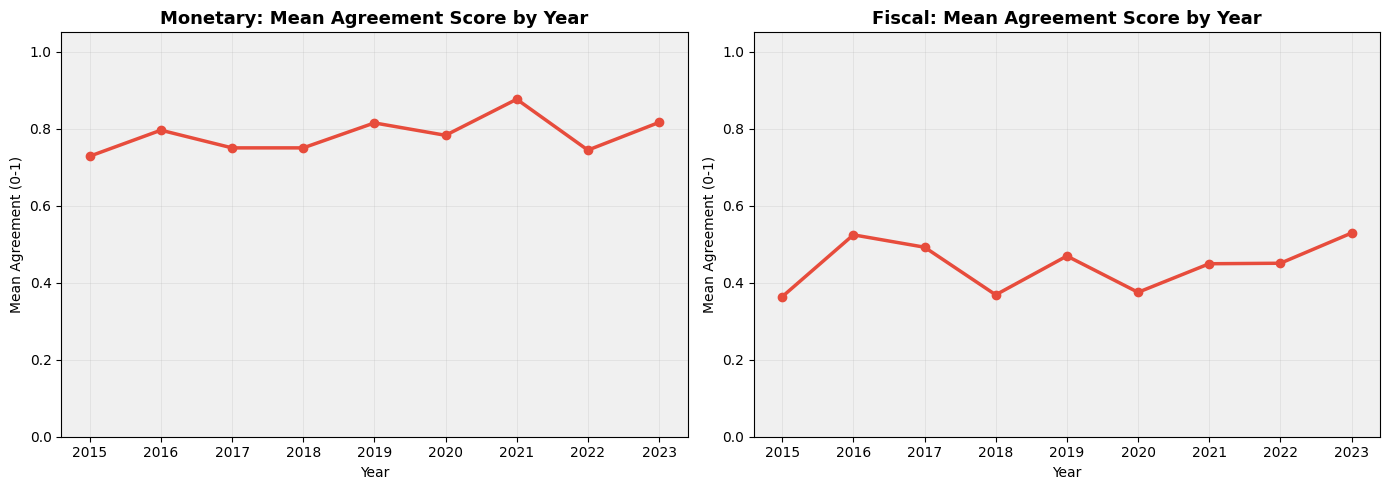

In [11]:
# Mean general agreement score by year (monetary & fiscal)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(axes,
    ["mon_agreement_general_bin", "fis_agreement_general_bin"],
    ["Monetary: Mean Agreement Score by Year",
     "Fiscal: Mean Agreement Score by Year"]):
    yearly = df.groupby("year")[col].mean()
    ax.plot(yearly.index, yearly.values, marker="o", linewidth=2.5, color="#E74C3C")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Mean Agreement (0-1)")
    ax.set_xticks(yearly.index)
    ax.set_ylim(0, 1.05)
    dv.style_axes(ax, grid=True, grid_axis="both")

plt.tight_layout()
plt.show()

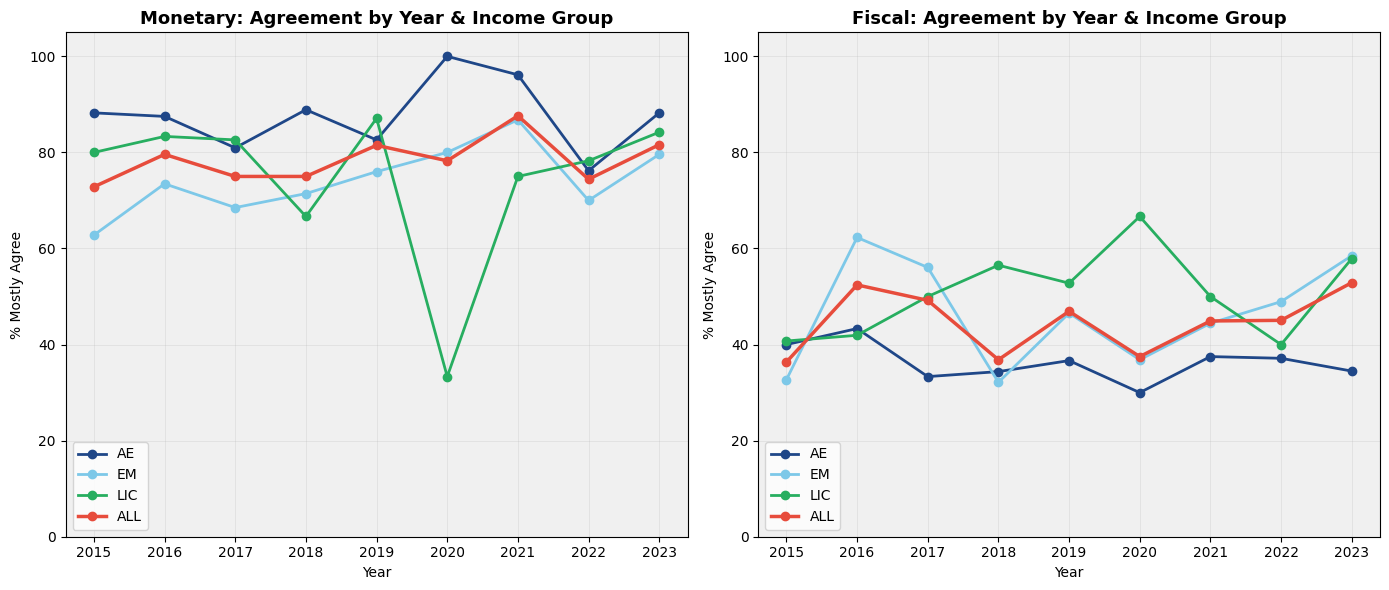

In [12]:
# Agreement by year x income group (monetary & fiscal)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, title in zip(axes,
    ["mon_agreement_general_bin", "fis_agreement_general_bin"],
    ["Monetary: Agreement by Year & Income Group",
     "Fiscal: Agreement by Year & Income Group"]):
    for g in INCOME_GROUP_ORDER:
        sub = df[df["income_group"] == g].groupby("year")[col].mean()
        ax.plot(sub.index, sub.values * 100, marker="o", linewidth=2,
                label=g, color=LINE_COLORS.get(g, "#333"))
    all_yr = df.groupby("year")[col].mean()
    ax.plot(all_yr.index, all_yr.values * 100, marker="o", linewidth=2.5,
            label="ALL", color=LINE_COLORS["ALL"])
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("% Mostly Agree")
    ax.set_xticks(all_yr.index)
    ax.set_ylim(0, 105)
    ax.legend(loc="lower left")
    dv.style_axes(ax, grid=True, grid_axis="both")

plt.tight_layout()
plt.show()

## Part 3: Monetary Policy

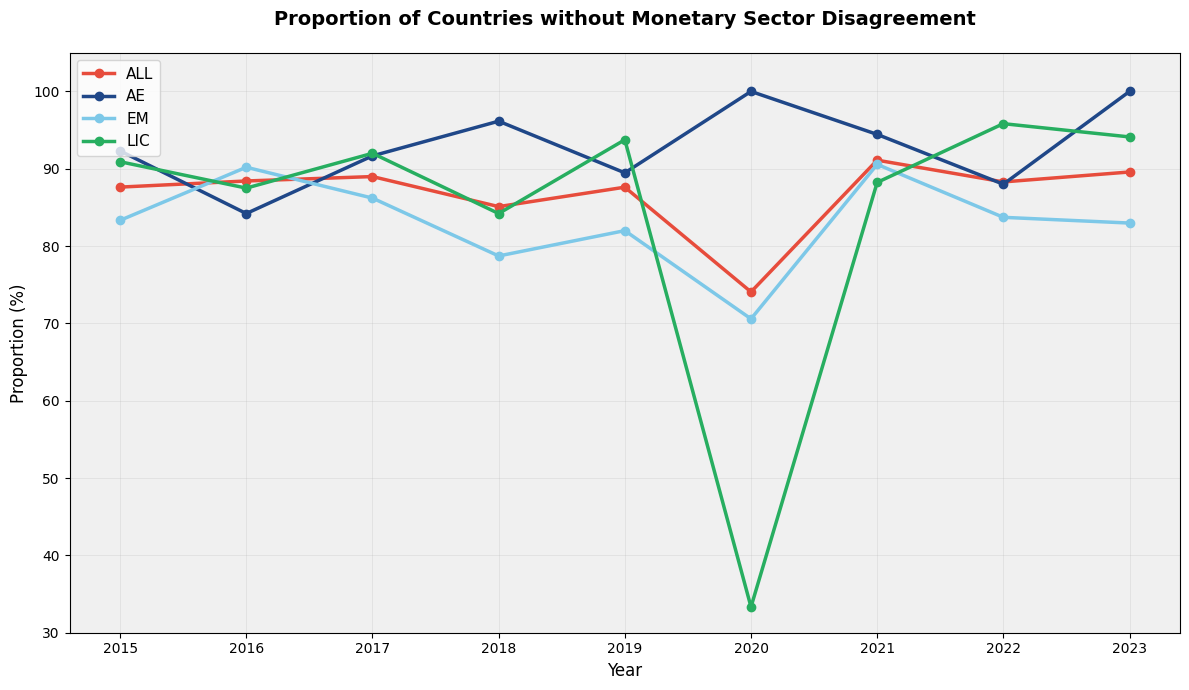

In [13]:
# Chart 2: Line — Proportion without Monetary Sector Disagreement
df_mon_ag = df[["Print ISBN", "year", "income_group", "mon_agreement"]].dropna(
    subset=["mon_agreement"]
).copy()
df_mon_ag = dv.add_no_disagreement_flag(df_mon_ag, agreement_col="mon_agreement")
mon_props = dv.compute_no_disagreement_proportions_by_year(
    df_mon_ag, year_col="year", flag_col="no_disagreement",
    group_col="income_group", groups=LINE_GROUPS,
)
dv.plot_group_lines_by_year(
    mon_props, groups=LINE_GROUPS, colors=LINE_COLORS,
    title="Proportion of Countries without Monetary Sector Disagreement",
    ylim=(30, 105),
)
plt.show()

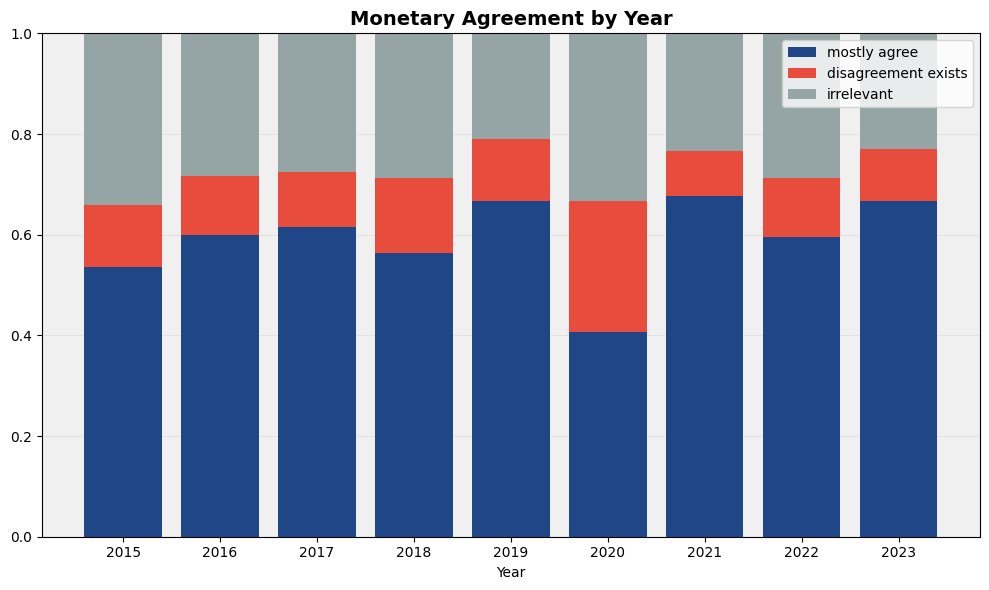

In [14]:
# Chart 3: Stacked bar — Monetary Agreement by Year
mon_agree_yr = (
    df.dropna(subset=["mon_agreement"])
    .groupby(["year", "mon_agreement"]).size().unstack(fill_value=0)
)
for c in AGREEMENT_ORDER:
    if c not in mon_agree_yr.columns:
        mon_agree_yr[c] = 0
mon_agree_yr = mon_agree_yr[AGREEMENT_ORDER]
mon_agree_share = mon_agree_yr.div(mon_agree_yr.sum(axis=1), axis=0)

dv.plot_stacked_proportions_by_year(
    mon_agree_share, order=AGREEMENT_ORDER, colors=AGREEMENT_COLORS,
    title="Monetary Agreement by Year", xtick_rotation=0,
)
plt.show()

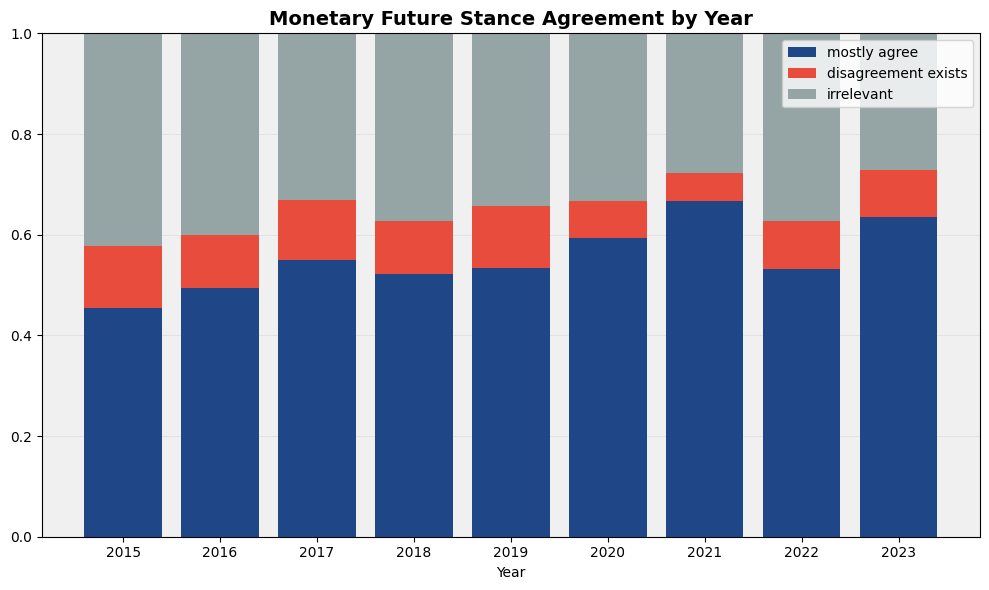

In [15]:
# Monetary stance-based agreement by year (future stance)
mon_sa = df.dropna(subset=["mon_agreement_stance_future"]).copy()
mon_sa_yr = mon_sa.groupby(["year", "mon_agreement_stance_future"]).size().unstack(fill_value=0)
for c in AGREEMENT_ORDER:
    if c not in mon_sa_yr.columns:
        mon_sa_yr[c] = 0
mon_sa_yr = mon_sa_yr[AGREEMENT_ORDER]
mon_sa_share = mon_sa_yr.div(mon_sa_yr.sum(axis=1), axis=0)

dv.plot_stacked_proportions_by_year(
    mon_sa_share, order=AGREEMENT_ORDER, colors=AGREEMENT_COLORS,
    title="Monetary Future Stance Agreement by Year", xtick_rotation=0,
)
plt.show()

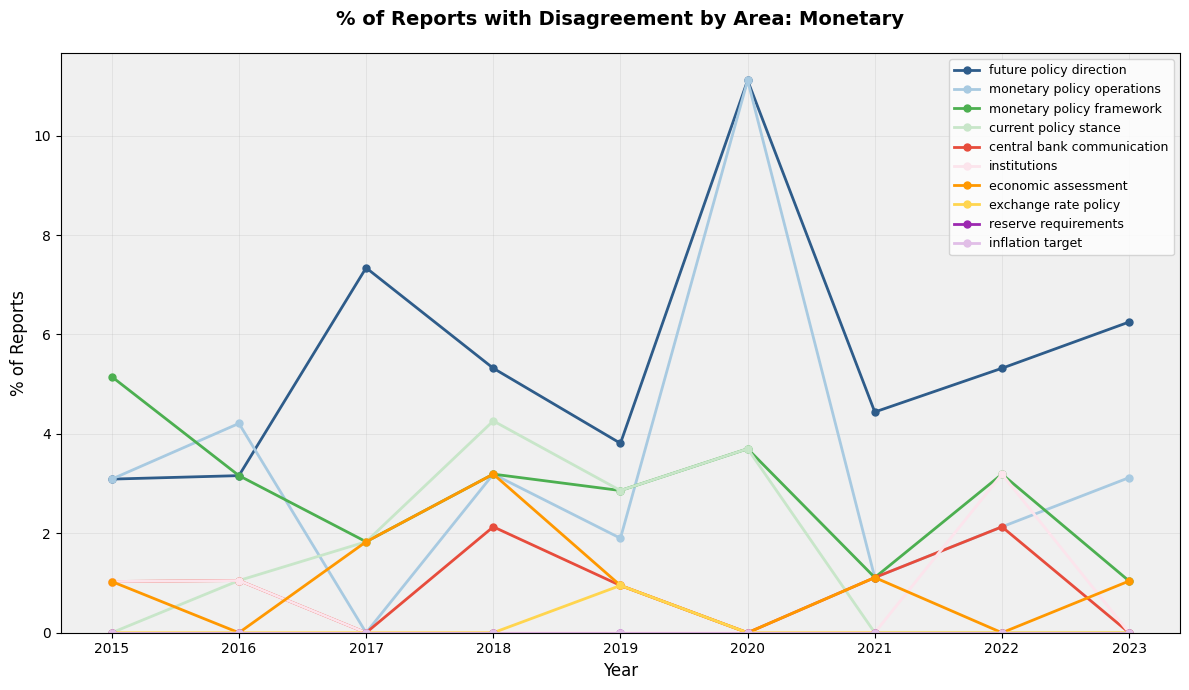

In [16]:
# Chart 4: Multi-line — % of Reports with Disagreement by Area: Monetary
df_mon_disagree = df[df["mon_agreement"] == "disagreement exists"].copy()
df_mon_disagree = dv.add_extracted_categories(
    df_mon_disagree, text_col="mon_disagreement_areas",
    categories=MONETARY_DISAGREE_CATEGORIES, out_col="categories",
)
df_mon_disagree_long = dv.explode_categories(
    df_mon_disagree, categories_col="categories", min_len=1,
)

total_mon_by_year = df.dropna(subset=["mon_agreement"]).groupby("year").size()
mon_cat_pct = dv.compute_category_percentage_by_year(
    df_mon_disagree_long, total_reports_by_year=total_mon_by_year,
    year_col="year", category_col="categories",
    category_order=list(MONETARY_DISAGREE_CATEGORIES.keys()),
)
dv.plot_category_trends(
    mon_cat_pct, categories=list(MONETARY_DISAGREE_CATEGORIES.keys()),
    colors=MONETARY_AREA_COLORS,
    title="% of Reports with Disagreement by Area: Monetary",
)
plt.show()

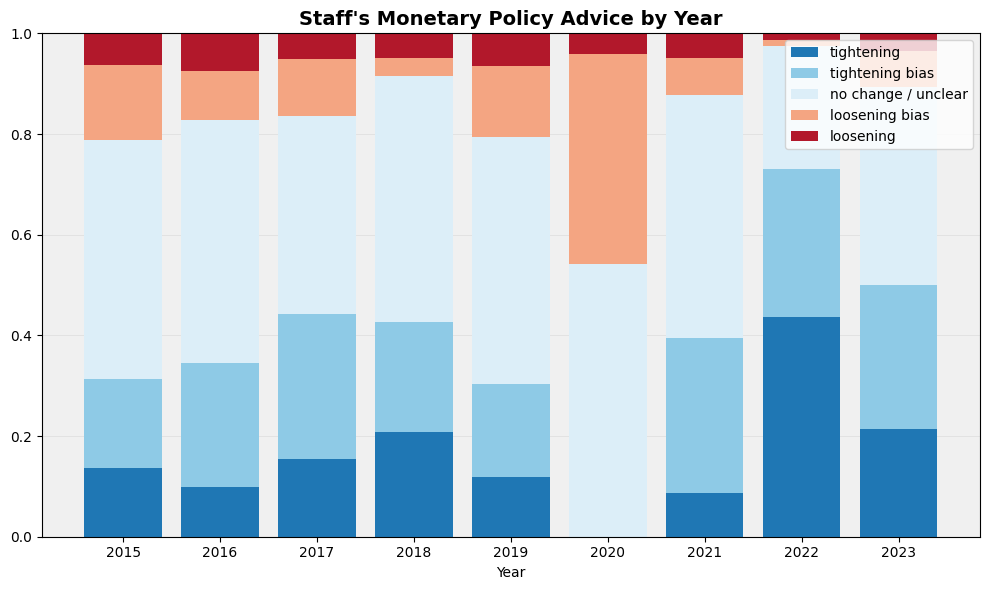

In [17]:
# Chart 5: Stacked bar — Staff's Monetary Policy Advice by Year
mon_staff_share = _stance_share_by_year(df, "mon_stance_future_staff", STANCE_ORDER)

dv.plot_stacked_proportions_by_year(
    mon_staff_share, order=STANCE_ORDER, colors=STANCE_COLORS,
    title="Staff's Monetary Policy Advice by Year", xtick_rotation=0,
)
plt.show()

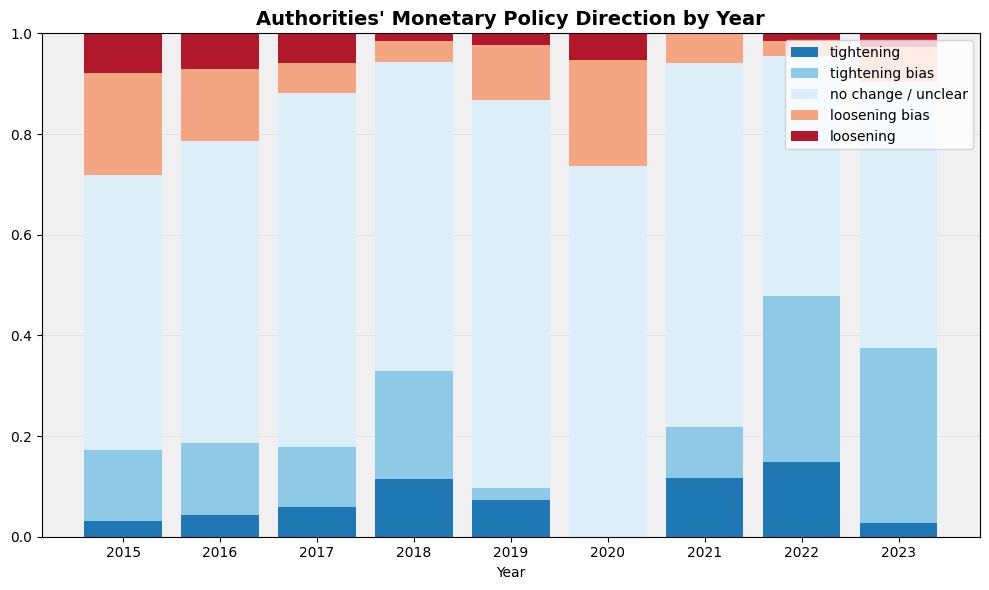

In [18]:
# Chart 6: Stacked bar — Authorities' Monetary Policy Direction by Year
mon_buff_share = _stance_share_by_year(df, "mon_stance_future_buff", STANCE_ORDER)

dv.plot_stacked_proportions_by_year(
    mon_buff_share, order=STANCE_ORDER, colors=STANCE_COLORS,
    title="Authorities' Monetary Policy Direction by Year", xtick_rotation=0,
)
plt.show()

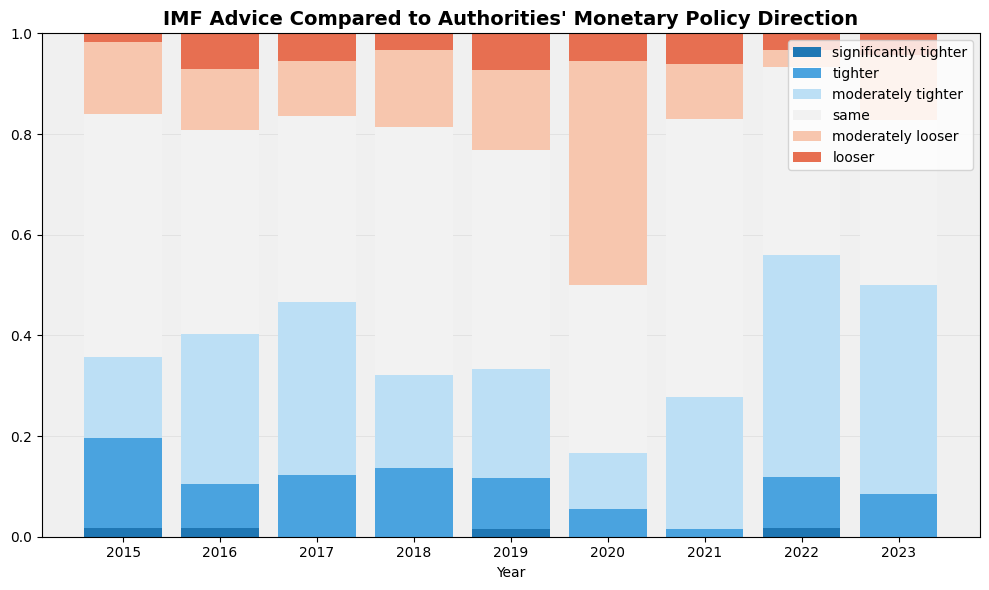

In [19]:
# Chart 7: Stacked bar — IMF Advice vs Authorities' Monetary Policy Direction
_mon_diff = df.dropna(subset=["mon_agreement_stance_future_num"]).copy()
_mon_diff["imf_vs_auth"] = _mon_diff["mon_agreement_stance_future_num"].apply(
    dv.bucket_imf_vs_auth_diff
)

imf_auth_yr = _mon_diff.groupby(["year", "imf_vs_auth"]).size().unstack(fill_value=0)
for cat in IMF_VS_AUTH_ORDER:
    if cat not in imf_auth_yr.columns:
        imf_auth_yr[cat] = 0
imf_auth_yr = imf_auth_yr[IMF_VS_AUTH_ORDER]
imf_auth_share = imf_auth_yr.div(imf_auth_yr.sum(axis=1), axis=0).fillna(0.0)

dv.plot_stacked_proportions_by_year(
    imf_auth_share, order=IMF_VS_AUTH_ORDER, colors=IMF_VS_AUTH_COLORS,
    title="IMF Advice Compared to Authorities' Monetary Policy Direction",
    xtick_rotation=0,
)
plt.show()

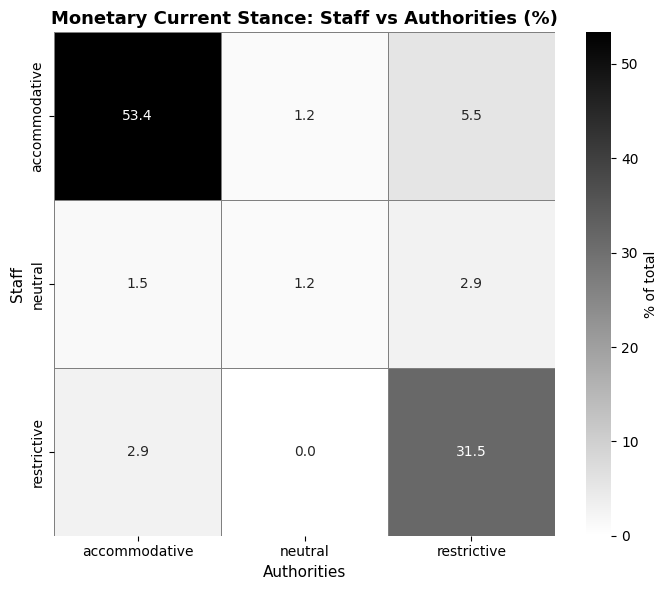

In [20]:
# Confusion matrix: monetary current stance (staff vs authorities)
mon_cur = df[
    df["mon_stance_current_staff"].isin(STANCE_CURRENT_ORDER)
    & df["mon_stance_current_buff"].isin(STANCE_CURRENT_ORDER)
].copy()

ct_cur = pd.crosstab(
    mon_cur["mon_stance_current_staff"],
    mon_cur["mon_stance_current_buff"],
    normalize="all",
) * 100
ct_cur = ct_cur.reindex(index=STANCE_CURRENT_ORDER, columns=STANCE_CURRENT_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(ct_cur, annot=True, fmt=".1f", cmap="binary", ax=ax,
            linewidths=0.5, linecolor="grey", cbar_kws={"label": "% of total"})
ax.set_title("Monetary Current Stance: Staff vs Authorities (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Authorities", fontsize=11)
ax.set_ylabel("Staff", fontsize=11)
plt.tight_layout()
plt.show()

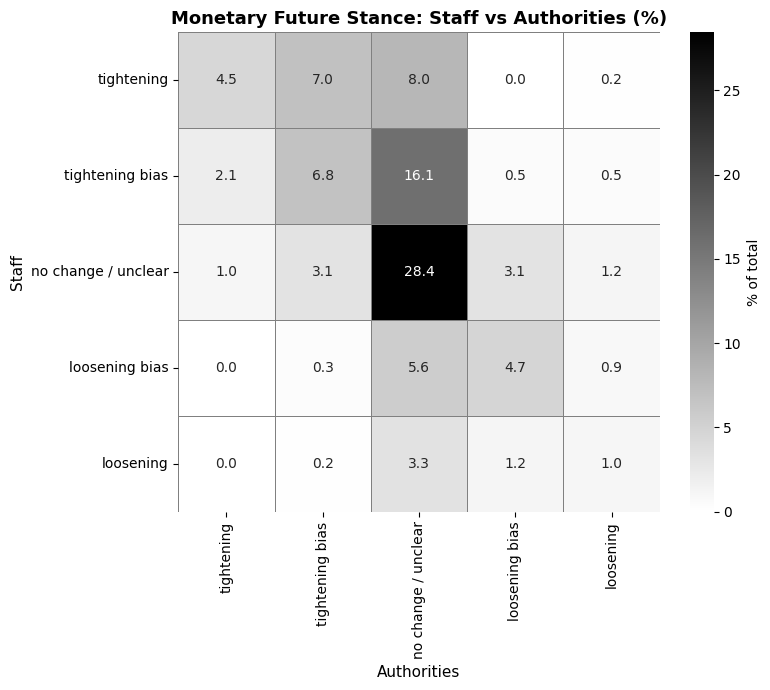

In [21]:
# Confusion matrix: monetary future stance (staff vs authorities)
mon_fut = df[
    df["mon_stance_future_staff"].isin(STANCE_ORDER)
    & df["mon_stance_future_buff"].isin(STANCE_ORDER)
].copy()

ct_fut = pd.crosstab(
    mon_fut["mon_stance_future_staff"],
    mon_fut["mon_stance_future_buff"],
    normalize="all",
) * 100
ct_fut = ct_fut.reindex(index=STANCE_ORDER, columns=STANCE_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(ct_fut, annot=True, fmt=".1f", cmap="binary", ax=ax,
            linewidths=0.5, linecolor="grey", cbar_kws={"label": "% of total"})
ax.set_title("Monetary Future Stance: Staff vs Authorities (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Authorities", fontsize=11)
ax.set_ylabel("Staff", fontsize=11)
plt.tight_layout()
plt.show()

## Part 4: Fiscal Policy

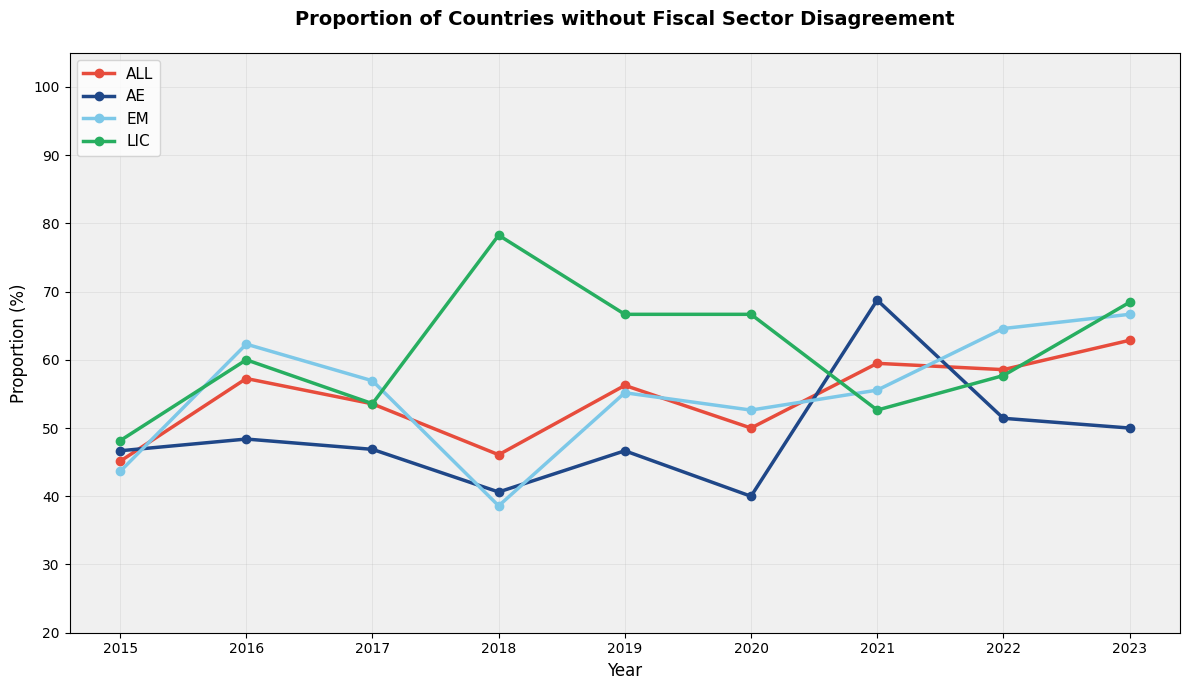

In [22]:
# Chart 8: Line — Proportion without Fiscal Sector Disagreement
df_fis_ag = df[["Print ISBN", "year", "income_group", "fis_agreement"]].dropna(
    subset=["fis_agreement"]
).copy()
df_fis_ag = dv.add_no_disagreement_flag(df_fis_ag, agreement_col="fis_agreement")
fis_props = dv.compute_no_disagreement_proportions_by_year(
    df_fis_ag, year_col="year", flag_col="no_disagreement",
    group_col="income_group", groups=LINE_GROUPS,
)
dv.plot_group_lines_by_year(
    fis_props, groups=LINE_GROUPS, colors=LINE_COLORS,
    title="Proportion of Countries without Fiscal Sector Disagreement",
    ylim=(20, 105),
)
plt.show()

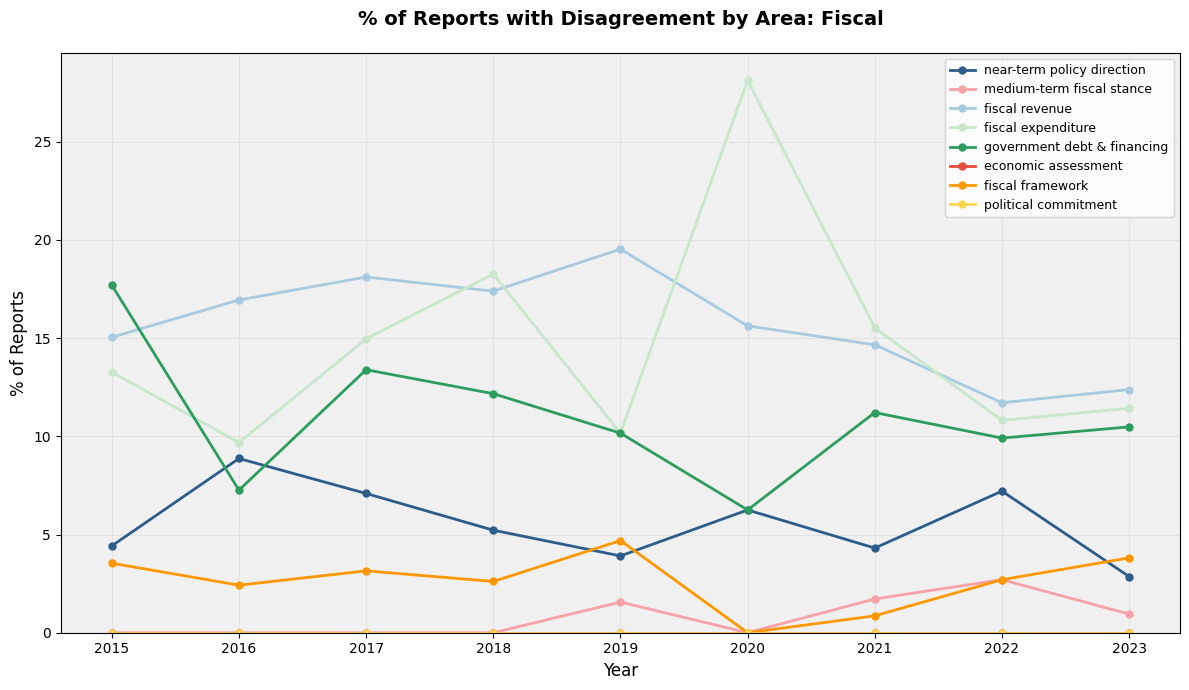

In [23]:
# Chart 9: Multi-line — % of Reports with Disagreement by Area: Fiscal
df_fis_disagree = df[df["fis_agreement"] == "disagreement exists"].copy()
df_fis_disagree = dv.add_extracted_categories(
    df_fis_disagree, text_col="fis_disagreement_areas",
    categories=FISCAL_DISAGREE_CATEGORIES, out_col="categories",
)
df_fis_disagree_long = dv.explode_categories(
    df_fis_disagree, categories_col="categories", min_len=1,
)

total_fis_by_year = df.dropna(subset=["fis_agreement"]).groupby("year").size()
fis_cat_pct = dv.compute_category_percentage_by_year(
    df_fis_disagree_long, total_reports_by_year=total_fis_by_year,
    year_col="year", category_col="categories",
    category_order=list(FISCAL_DISAGREE_CATEGORIES.keys()),
)
dv.plot_category_trends(
    fis_cat_pct, categories=list(FISCAL_DISAGREE_CATEGORIES.keys()),
    colors=FISCAL_AREA_COLORS,
    title="% of Reports with Disagreement by Area: Fiscal",
)
plt.show()

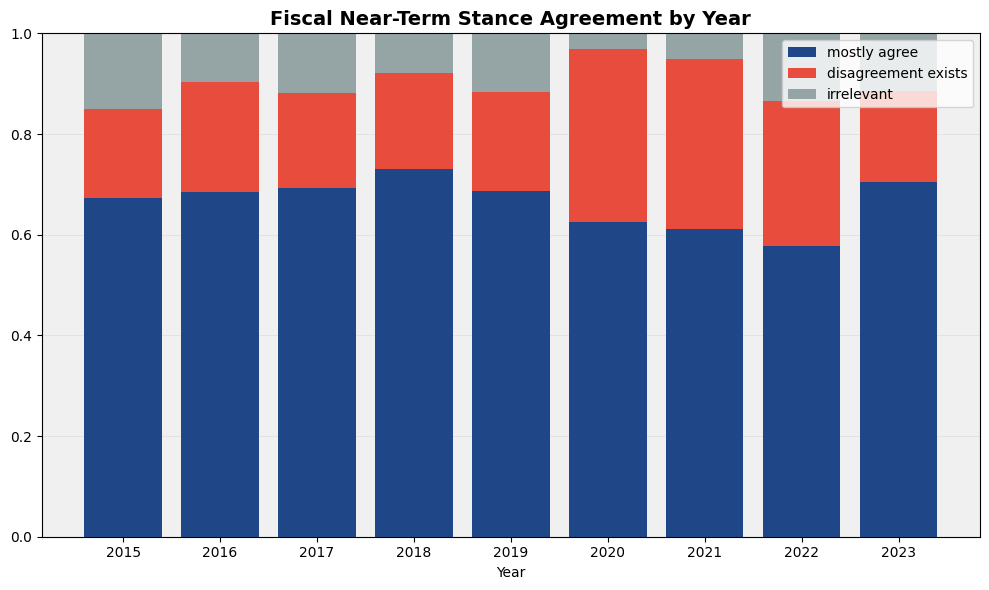

In [24]:
# Fiscal stance-based agreement by year (near-term stance)
fis_sa = df.dropna(subset=["fis_agreement_stance_near_term"]).copy()
fis_sa_yr = fis_sa.groupby(["year", "fis_agreement_stance_near_term"]).size().unstack(fill_value=0)
for c in AGREEMENT_ORDER:
    if c not in fis_sa_yr.columns:
        fis_sa_yr[c] = 0
fis_sa_yr = fis_sa_yr[AGREEMENT_ORDER]
fis_sa_share = fis_sa_yr.div(fis_sa_yr.sum(axis=1), axis=0)

dv.plot_stacked_proportions_by_year(
    fis_sa_share, order=AGREEMENT_ORDER, colors=AGREEMENT_COLORS,
    title="Fiscal Near-Term Stance Agreement by Year", xtick_rotation=0,
)
plt.show()

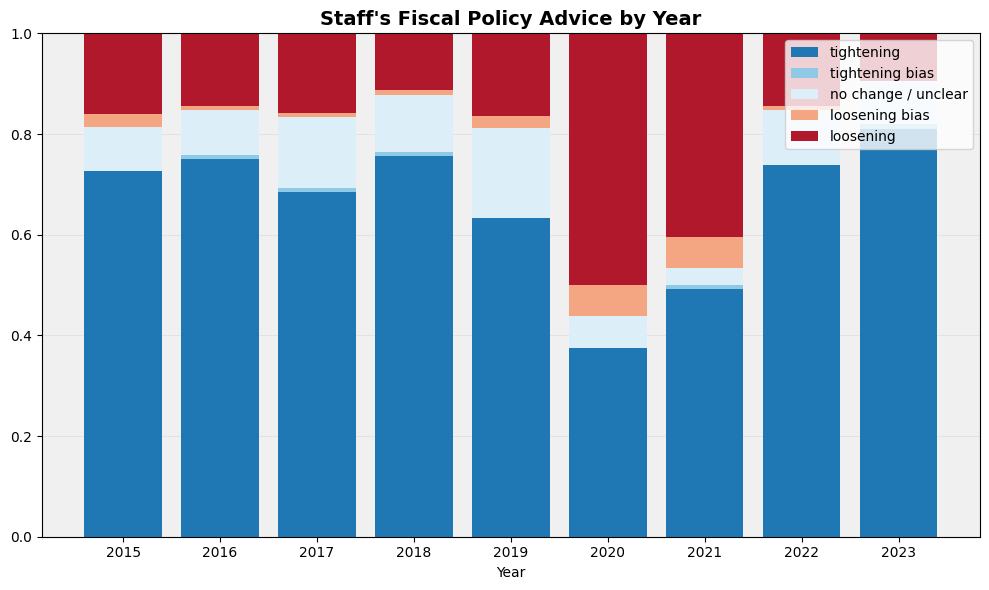

In [25]:
# Chart 10: Stacked bar — Staff's Fiscal Policy Advice by Year
fis_staff_share = _stance_share_by_year(df, "fis_stance_near_term_staff", STANCE_ORDER)

dv.plot_stacked_proportions_by_year(
    fis_staff_share, order=STANCE_ORDER, colors=STANCE_COLORS,
    title="Staff's Fiscal Policy Advice by Year", xtick_rotation=0,
)
plt.show()

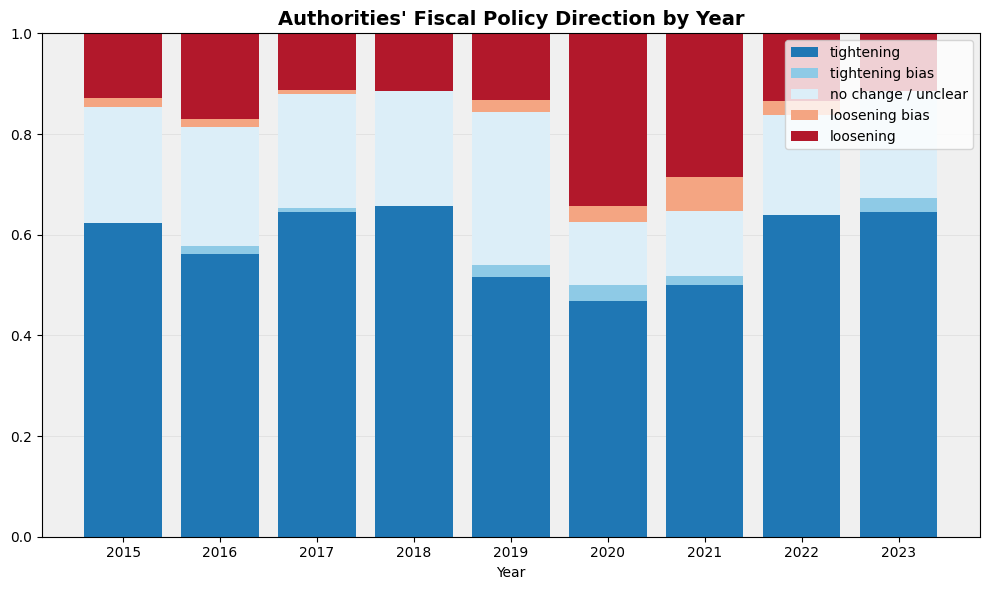

In [26]:
# Chart 11: Stacked bar — Authorities' Fiscal Policy Direction by Year
fis_buff_share = _stance_share_by_year(df, "fis_stance_near_term_buff", STANCE_ORDER)

dv.plot_stacked_proportions_by_year(
    fis_buff_share, order=STANCE_ORDER, colors=STANCE_COLORS,
    title="Authorities' Fiscal Policy Direction by Year", xtick_rotation=0,
)
plt.show()

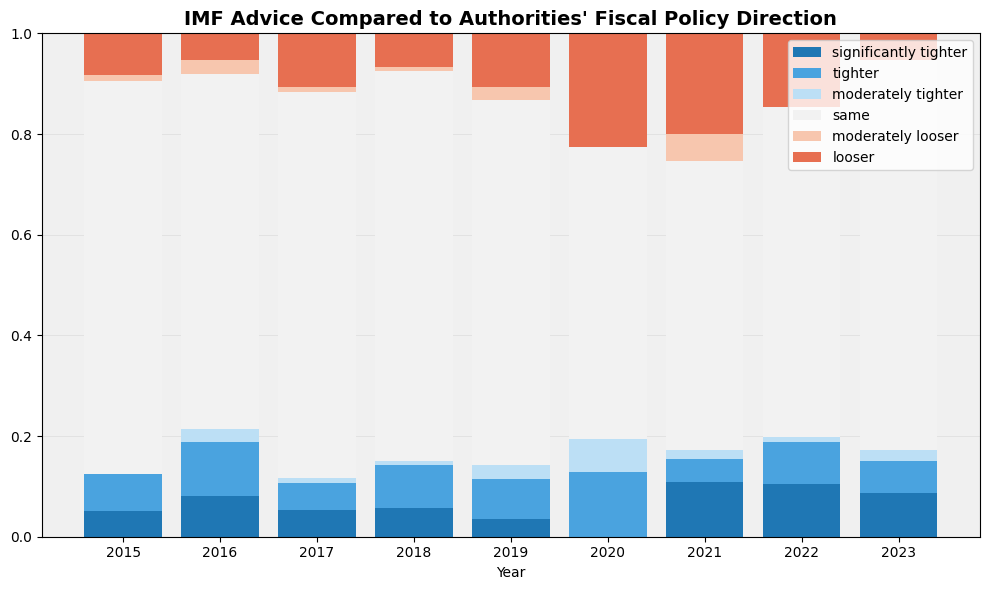

In [27]:
# Chart 12: Stacked bar — IMF Advice vs Authorities' Fiscal Policy Direction
_fis_diff = df.dropna(subset=["fis_agreement_stance_near_term_num"]).copy()
_fis_diff["imf_vs_auth"] = _fis_diff["fis_agreement_stance_near_term_num"].apply(
    dv.bucket_imf_vs_auth_diff
)

fis_imf_auth_yr = _fis_diff.groupby(["year", "imf_vs_auth"]).size().unstack(fill_value=0)
for cat in IMF_VS_AUTH_ORDER:
    if cat not in fis_imf_auth_yr.columns:
        fis_imf_auth_yr[cat] = 0
fis_imf_auth_yr = fis_imf_auth_yr[IMF_VS_AUTH_ORDER]
fis_imf_auth_share = fis_imf_auth_yr.div(fis_imf_auth_yr.sum(axis=1), axis=0).fillna(0.0)

dv.plot_stacked_proportions_by_year(
    fis_imf_auth_share, order=IMF_VS_AUTH_ORDER, colors=IMF_VS_AUTH_COLORS,
    title="IMF Advice Compared to Authorities' Fiscal Policy Direction",
    xtick_rotation=0,
)
plt.show()

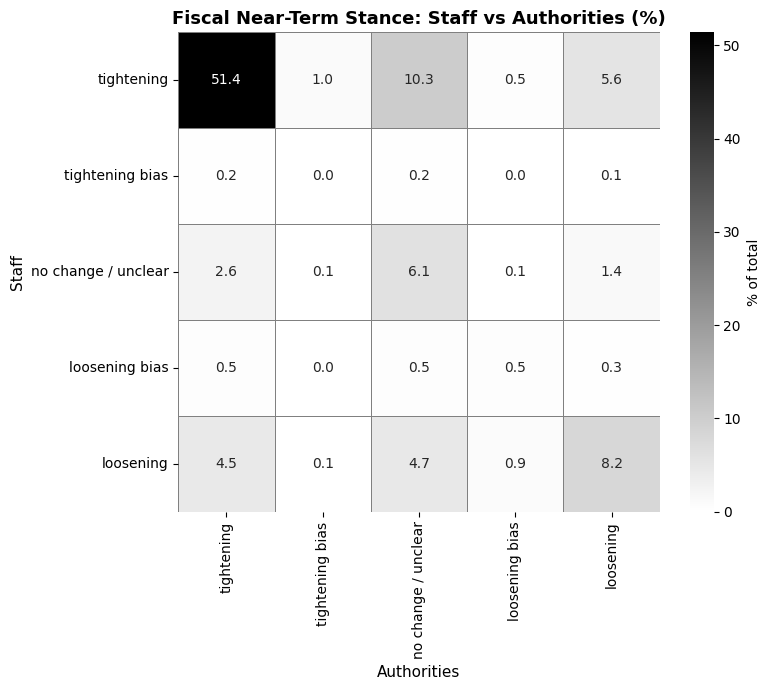

In [28]:
# Confusion matrix: fiscal near-term stance (staff vs authorities)
fis_nt = df[
    df["fis_stance_near_term_staff"].isin(STANCE_ORDER)
    & df["fis_stance_near_term_buff"].isin(STANCE_ORDER)
].copy()

ct_fis_nt = pd.crosstab(
    fis_nt["fis_stance_near_term_staff"],
    fis_nt["fis_stance_near_term_buff"],
    normalize="all",
) * 100
ct_fis_nt = ct_fis_nt.reindex(index=STANCE_ORDER, columns=STANCE_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(ct_fis_nt, annot=True, fmt=".1f", cmap="binary", ax=ax,
            linewidths=0.5, linecolor="grey", cbar_kws={"label": "% of total"})
ax.set_title("Fiscal Near-Term Stance: Staff vs Authorities (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Authorities", fontsize=11)
ax.set_ylabel("Staff", fontsize=11)
plt.tight_layout()
plt.show()

## Part 5: Policy Mix (Cross-Sector)

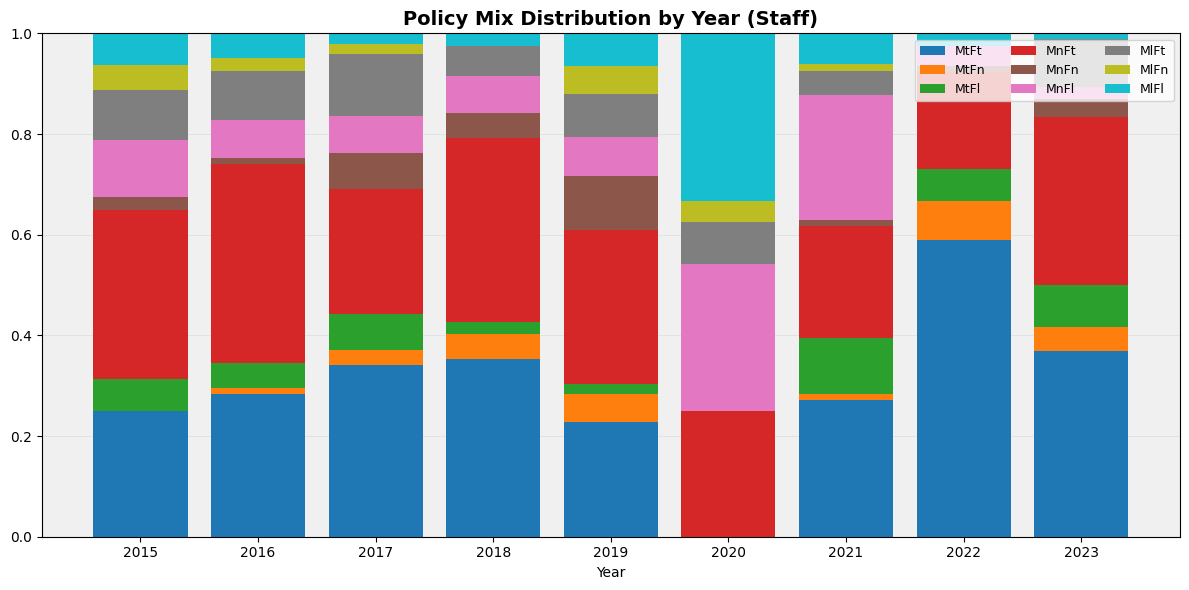

In [29]:
# Policy mix distribution by year — staff
pm_staff = df.dropna(subset=["policy_mix_staff"]).groupby(["year", "policy_mix_staff"]).size().unstack(fill_value=0)
for c in POLICY_MIX_ORDER:
    if c not in pm_staff.columns:
        pm_staff[c] = 0
pm_staff = pm_staff[POLICY_MIX_ORDER]
pm_staff_share = pm_staff.div(pm_staff.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(pm_staff_share))
for i, cat in enumerate(POLICY_MIX_ORDER):
    vals = pm_staff_share[cat].values
    ax.bar(pm_staff_share.index, vals, bottom=bottom, label=cat,
           color=POLICY_MIX_CMAP(i), edgecolor="none")
    bottom += vals
ax.set_title("Policy Mix Distribution by Year (Staff)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right", fontsize=9, ncol=3)
ax.set_xticks(pm_staff_share.index)
dv.style_axes(ax, grid=True, grid_axis="y")
plt.tight_layout()
plt.show()

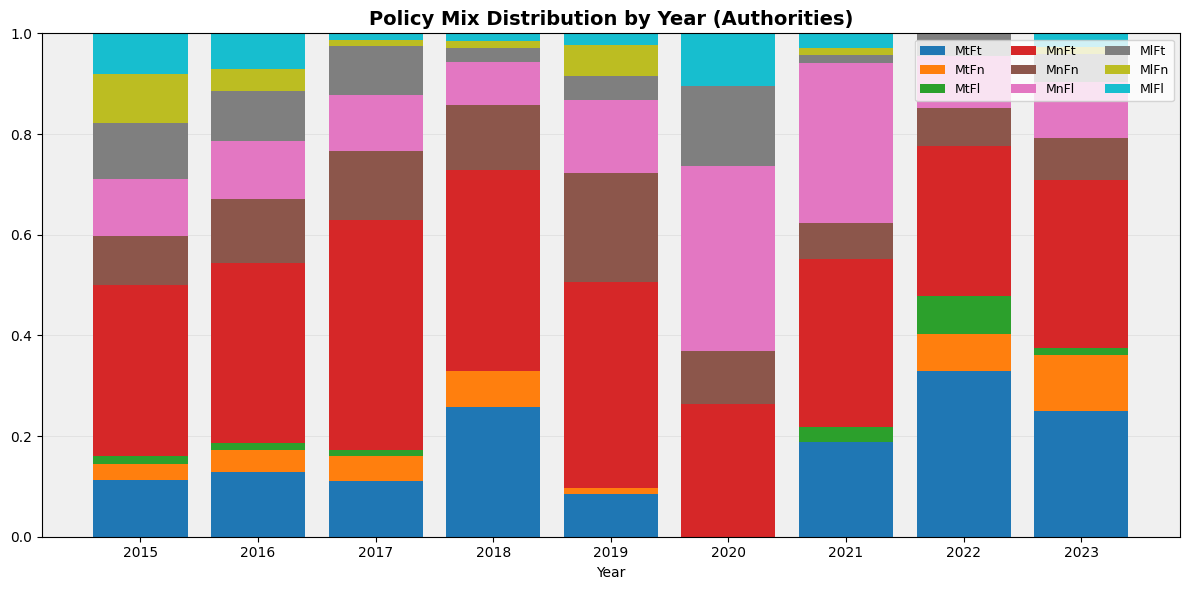

In [30]:
# Policy mix distribution by year — authorities
pm_buff = df.dropna(subset=["policy_mix_buff"]).groupby(["year", "policy_mix_buff"]).size().unstack(fill_value=0)
for c in POLICY_MIX_ORDER:
    if c not in pm_buff.columns:
        pm_buff[c] = 0
pm_buff = pm_buff[POLICY_MIX_ORDER]
pm_buff_share = pm_buff.div(pm_buff.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(12, 6))
bottom = np.zeros(len(pm_buff_share))
for i, cat in enumerate(POLICY_MIX_ORDER):
    vals = pm_buff_share[cat].values
    ax.bar(pm_buff_share.index, vals, bottom=bottom, label=cat,
           color=POLICY_MIX_CMAP(i), edgecolor="none")
    bottom += vals
ax.set_title("Policy Mix Distribution by Year (Authorities)", fontsize=14, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylim(0, 1.0)
ax.legend(loc="upper right", fontsize=9, ncol=3)
ax.set_xticks(pm_buff_share.index)
dv.style_axes(ax, grid=True, grid_axis="y")
plt.tight_layout()
plt.show()

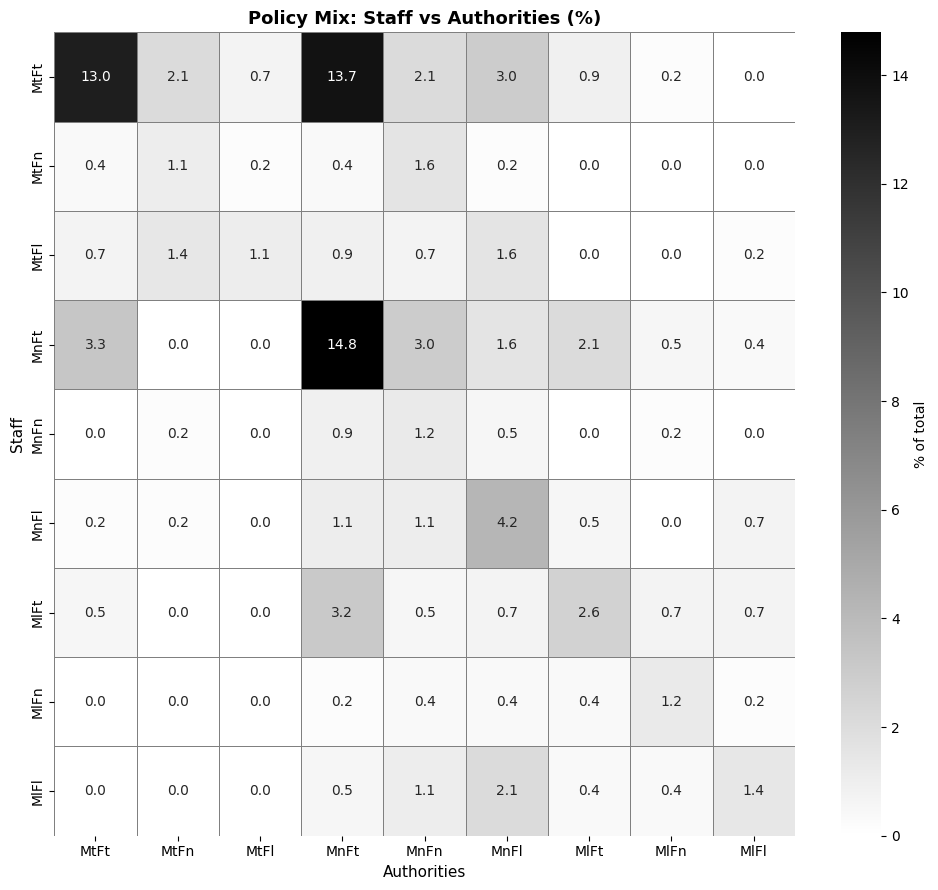

In [31]:
# Confusion matrix: policy mix staff vs authorities
pm_both = df.dropna(subset=["policy_mix_staff", "policy_mix_buff"]).copy()

ct_pm = pd.crosstab(
    pm_both["policy_mix_staff"], pm_both["policy_mix_buff"], normalize="all"
) * 100
ct_pm = ct_pm.reindex(index=POLICY_MIX_ORDER, columns=POLICY_MIX_ORDER, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(ct_pm, annot=True, fmt=".1f", cmap="binary", ax=ax,
            linewidths=0.5, linecolor="grey", cbar_kws={"label": "% of total"})
ax.set_title("Policy Mix: Staff vs Authorities (%)", fontsize=13, fontweight="bold")
ax.set_xlabel("Authorities", fontsize=11)
ax.set_ylabel("Staff", fontsize=11)
plt.tight_layout()
plt.show()

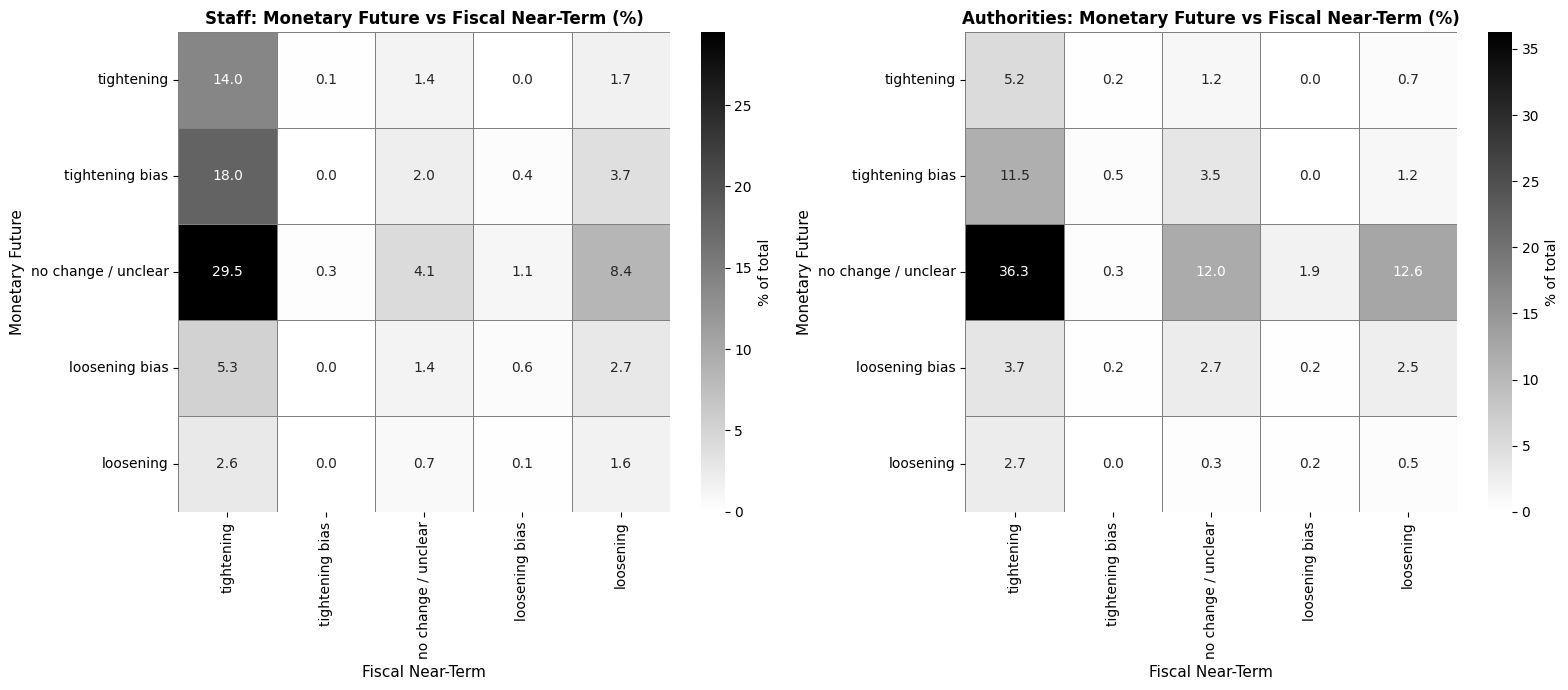

In [32]:
# Cross-sectoral confusion matrices: monetary future vs fiscal near-term
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, staff_col, fis_col, title in zip(axes,
    ["mon_stance_future_staff", "mon_stance_future_buff"],
    ["fis_stance_near_term_staff", "fis_stance_near_term_buff"],
    ["Staff: Monetary Future vs Fiscal Near-Term (%)",
     "Authorities: Monetary Future vs Fiscal Near-Term (%)"]):
    cross = df[
        df[staff_col].isin(STANCE_ORDER) & df[fis_col].isin(STANCE_ORDER)
    ].copy()
    ct = pd.crosstab(cross[staff_col], cross[fis_col], normalize="all") * 100
    ct = ct.reindex(index=STANCE_ORDER, columns=STANCE_ORDER, fill_value=0)
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="binary", ax=ax,
                linewidths=0.5, linecolor="grey", cbar_kws={"label": "% of total"})
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Fiscal Near-Term", fontsize=11)
    ax.set_ylabel("Monetary Future", fontsize=11)

plt.tight_layout()
plt.show()

## Part 6: Summary Statistics

In [33]:
# Key variable value counts
summary_cols = [
    "mon_agreement", "fis_agreement",
    "mon_agreement_general", "fis_agreement_general",
    "mon_agreement_stance_current", "mon_agreement_stance_future",
    "fis_agreement_stance_near_term",
    "agreement_overall",
]

for col in summary_cols:
    if col in df.columns:
        print(f"\n{'='*60}")
        print(f"{col}:")
        print(df[col].value_counts(dropna=False))
        print(f"{'='*60}")


mon_agreement:
mon_agreement
mostly agree           491
irrelevant             218
NaN                    174
disagreement exists     98
Name: count, dtype: int64

fis_agreement:
fis_agreement
mostly agree           500
disagreement exists    440
irrelevant              31
NaN                     10
Name: count, dtype: int64

mon_agreement_general:
mon_agreement_general
mostly agree           604
irrelevant             213
disagreement exists    164
Name: count, dtype: int64

fis_agreement_general:
fis_agreement_general
disagreement exists    529
mostly agree           440
irrelevant              12
Name: count, dtype: int64

mon_agreement_stance_current:
mon_agreement_stance_current
irrelevant             464
mostly agree           295
NaN                    174
disagreement exists     48
Name: count, dtype: int64

mon_agreement_stance_future:
mon_agreement_stance_future
mostly agree           443
irrelevant             281
NaN                    174
disagreement exists     83
Name: 

In [34]:
# Cross-tabs: agreement x income group, agreement x year
print("Monetary agreement x income group:")
print(pd.crosstab(df["income_group"], df["mon_agreement_general"], margins=True))

print("\nFiscal agreement x income group:")
print(pd.crosstab(df["income_group"], df["fis_agreement_general"], margins=True))

print("\nOverall agreement x income group:")
print(pd.crosstab(df["income_group"], df["agreement_overall"], margins=True))

print("\nMonetary agreement x year:")
print(pd.crosstab(df["year"], df["mon_agreement_general"], margins=True))

print("\nFiscal agreement x year:")
print(pd.crosstab(df["year"], df["fis_agreement_general"], margins=True))

Monetary agreement x income group:
mon_agreement_general  disagreement exists  irrelevant  mostly agree  All
income_group                                                             
AE                                      23          90           149  262
EM                                     104          79           298  481
LIC                                     36          37           141  214
All                                    163         206           588  957

Fiscal agreement x income group:
fis_agreement_general  disagreement exists  irrelevant  mostly agree  All
income_group                                                             
AE                                     163           4            95  262
EM                                     249           6           226  481
LIC                                    109           2           103  214
All                                    521          12           424  957

Overall agreement x income group:
agreemen